# Crazyflie active-sensing observability example

This notebook mirrors `references/pybounds_examples/fly_wind_example.ipynb`, but uses **this
project's own crazyflie-like drone model** (`model/drone_simulator.py`) instead of the
insect/wind model.

The question we're asking is the one from `elaborate_plan.md` Phase 1: with only an optical-flow
sensor (like the Flow deck v2) and an accelerometer (the onboard IMU) -- i.e. **no direct height
sensor** -- when does altitude `z` actually become observable? The reference paper
(`references/summaries/bens_epic_paper.md`) found that altitude is only observable during
**horizontal acceleration/deceleration**, not during hover or turning, because optic flow only
measures the ratio `velocity / z`. We replicate that same empirical-observability analysis here,
using our own model's dynamics instead of assuming the paper's result transfers unchanged.

# Install pybounds and requirements

This should allow the notebook to run directly in google colab.

In [1]:
try:
  import casadi
except:
  !pip install casadi
  import casadi

try:
  import do_mpc
except:
  !pip install do_mpc
  import do_mpc

try:
  import pybounds
except:
  !pip install pybounds
  import pybounds

/home/cherry/Documents/ai_kalman_on_crazyflie/.venv/lib/python3.12/site-packages/do_mpc/sysid/__init__.py:15: UserWarning: The ONNX feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The ONNX feature is not available. Please install the full version of do-mpc to access this feature.')
/home/cherry/Documents/ai_kalman_on_crazyflie/.venv/lib/python3.12/site-packages/do_mpc/opcua/__init__.py:14: UserWarning: The opcua feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The opcua feature is not available. Please install the full version of do-mpc to access this feature.')
/home/cherry/Documents/ai_kalman_on_crazyflie/.venv/lib/python3.12/site-packages/do_mpc/approximateMPC/__init__.py:13: UserWarning: The approximateMPC feature requires PyTorch, which is not installed by default. Please install the full version of do-mpc to use this feature: pip install do_mpc[full]
  warnings

# Import packages

In [2]:
import sys
import os
sys.path.append(os.path.abspath('.'))

import time
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from pybounds import SlidingEmpiricalObservabilityMatrix, FisherObservability, SlidingFisherObservability, ObservabilityMatrixImage, colorline

# This project's crazyflie-like drone model
from model.drone_simulator import DroneModel, DroneSimulator

### Compatibility shim (newer numpy)

Some numpy releases no longer allow implicit conversion of a size-1, non-0-d array to a Python
scalar via `int()`/`np.round()`. `do_mpc` passes its internal time (`self._t0`, shape `(1,)`) into
`pybounds.Simulator.simulator_tvp_function`/`mpc_tvp_function`, which do exactly that conversion,
so on such numpy versions `simulator.simulate(mpc=True)` raises
`TypeError: only 0-dimensional arrays can be converted to Python scalars`.

This cell patches around it at runtime (no installs, no version changes) by coercing `t` to a
plain float before handing it to the original methods. It must run before `DroneSimulator(...)`
is instantiated below, since `Simulator.__init__` captures these methods as callbacks.

In [3]:
from pybounds import Simulator as _PyBoundsSimulator


def _scalar_time(t):
    """Coerce a possibly-array-shaped time value to a plain Python float."""
    return float(np.asarray(t).reshape(-1)[0])


_orig_simulator_tvp_function = _PyBoundsSimulator.simulator_tvp_function
_orig_mpc_tvp_function = _PyBoundsSimulator.mpc_tvp_function


def _patched_simulator_tvp_function(self, t):
    return _orig_simulator_tvp_function(self, _scalar_time(t))


def _patched_mpc_tvp_function(self, t):
    return _orig_mpc_tvp_function(self, _scalar_time(t))


_PyBoundsSimulator.simulator_tvp_function = _patched_simulator_tvp_function
_PyBoundsSimulator.mpc_tvp_function = _patched_mpc_tvp_function

# Define system dynamics and measurements

This example uses `model/drone_simulator.py`'s `DroneModel`/`DroneSimulator`, a planar-drone model
adapted for a hovering, GPS-denied quadcopter (i.e. a Crazyflie) rather than a free-flying insect.

The system dynamics are described by twelve states (in the body-level, moving-frame
configuration we use below):
* `x`, `y` - position in the inertial frame [m]
* `z` - altitude [m]
* `v_x`, `v_y` - body-level forward/lateral velocity [m/s]
* `v_z` - vertical velocity [m/s]
* `psi` - yaw heading [rad]
* `w`, `zeta` - ambient wind speed/direction (kept at 0 here -- there is no meaningful ambient
  wind for an indoor Crazyflie flight, but the state exists for model generality / reuse of the
  same model class outdoors)
* `k_x`, `k_y`, `k_psi` - motor/velocity-control calibration coefficients

with inputs `u_x`, `u_y` (body-level accelerations), `u_psi` (yaw rate), `u_z` (vertical
acceleration), `u_w`, `u_zeta` (wind rate of change).

The measurement function returns every state and input (useful for observability experiments --
you can ask "what if I had a direct sensor for this state"), plus a set of derived measurements
that map directly onto real Crazyflie hardware:
* `r_x = v_x / z`, `r_y = v_y / z` -- **optical flow** in body x/y, exactly what the Flow deck v2
  (PMW3901) provides. Note this is the same velocity/height ambiguity the reference paper's
  altitude sub-problem is built around.
* `v_x_dot`, `v_y_dot` -- body-level accelerations (including rotational-coupling terms), the
  closest analog to the onboard **accelerometer**.
* `g`, `beta` -- ground speed magnitude/angle.
* `a_x`, `a_y`, `a`, `gamma` -- apparent airflow (not physically available on a Crazyflie -- no
  airspeed sensor -- included only because the model is shared with the outdoor flying-agent case).
* `w_x`, `w_y` -- wind components (likewise not relevant indoors).

For the "impaired sensor" scenario (no direct height sensor, matching the project's grand-prize
goal), the only measurements we assume are available are `r_x`, `r_y` (flow deck) and `v_x_dot`,
`v_y_dot` (IMU accelerometer). We compare that against a "full sensor" baseline that also includes
`z` directly (as if a ToF/height sensor were present), which should trivially make `z` observable
everywhere.

# Create simulator object

In [4]:
dt = 0.1  # [s]

simulator = DroneSimulator(frame='body_level', moving_frame='on', dt=dt, mpc_horizon=10)

print('states:', simulator.state_names)
print('inputs:', simulator.input_names)
print('measurements:', simulator.measurement_names)

states: ['x', 'y', 'z', 'v_x', 'v_y', 'v_z', 'psi', 'w', 'zeta', 'k_x', 'k_y', 'k_psi']
inputs: ['u_x', 'u_y', 'u_psi', 'u_z', 'u_w', 'u_zeta']
measurements: ['x', 'y', 'z', 'v_x', 'v_y', 'v_z', 'psi', 'w', 'zeta', 'k_x', 'k_y', 'k_psi', 'u_x', 'u_y', 'u_psi', 'u_z', 'u_w', 'u_zeta', 'v_x_dot', 'v_y_dot', 'r_x', 'r_y', 'r', 'g', 'beta', 'a_x', 'a_y', 'a', 'gamma', 'w_x', 'w_y']


# Design a flight trajectory: distinct active-sensing motifs

We hold altitude at a constant setpoint throughout (an altitude-hold hover, like a real indoor
Crazyflie flight) and keep ambient wind at 0, then move through five segments so we can directly
compare observability during different motifs:

1. **Hover** (0-5s): `v_x = v_y = 0` -- baseline, no horizontal motion.
2. **Horizontal acceleration/deceleration pulse** (5-9s): `v_x` ramps 0 -> 1.2 m/s -> 0. This is
   the motif the reference paper predicts is required for `z` to become observable from
   flow+accel alone.
3. **Hover** (9-14s): back to baseline, for contrast.
4. **Heading turn** (14-18s): `psi` ramps 0 -> pi/2 with `v_x = v_y = 0` throughout (an
   offset-turn-style motif). Included specifically to test whether turning *also* helps `z`
   observability, or whether (per the paper) only horizontal acceleration does.
5. **Hover** (18-24s): final baseline segment.

In [5]:
T = 24.0  # total trajectory duration [s]
tsim = np.arange(0, T + dt / 2, step=dt)
N = len(tsim)


def ramp_segment(arr, t0, t1, v0, v1):
    """Linearly ramp arr from v0 to v1 between times t0 and t1, holding v1 after t1."""
    i0 = int(round(t0 / dt))
    i1 = int(round(t1 / dt))
    arr[i0:i1] = np.linspace(v0, v1, i1 - i0)
    arr[i1:] = v1


v_x = np.zeros(N)
v_y = np.zeros(N)
psi = np.zeros(N)
z_set = 1.5 * np.ones(N)  # constant altitude-hold setpoint [m]
w_set = np.zeros(N)       # no ambient wind (indoor flight)
zeta_set = np.zeros(N)

# Segment 2: horizontal acceleration / deceleration pulse
ramp_segment(v_x, 5.0, 7.0, 0.0, 1.2)
ramp_segment(v_x, 7.0, 9.0, 1.2, 0.0)

# Segment 4: heading turn (offset turn), no horizontal velocity
ramp_segment(psi, 14.0, 18.0, 0.0, np.pi / 2)

# Motif segment boundaries, used later for plotting/annotation
motif_segments = [
    (0.0, 5.0, 'hover'),
    (5.0, 9.0, 'accel/decel pulse'),
    (9.0, 14.0, 'hover'),
    (14.0, 18.0, 'heading turn'),
    (18.0, T, 'hover'),
]

simulator.update_setpoint(z=z_set, v_x=v_x, v_y=v_y, psi=psi, w=w_set, zeta=zeta_set)

# Run model predictive control

Note that the cost function defined in `DroneSimulator` (altitude, wind, heading, and body-level
velocity tracking) & the controllability of each state will determine how closely the setpoint
trajectory above is tracked.

In [6]:
st = time.time()
t_sim, x_sim, u_sim, y_sim = simulator.simulate(x0=None, mpc=True, return_full_output=True)
et = time.time()
print('elapsed time:', et - st)

elapsed time: 9.459252834320068


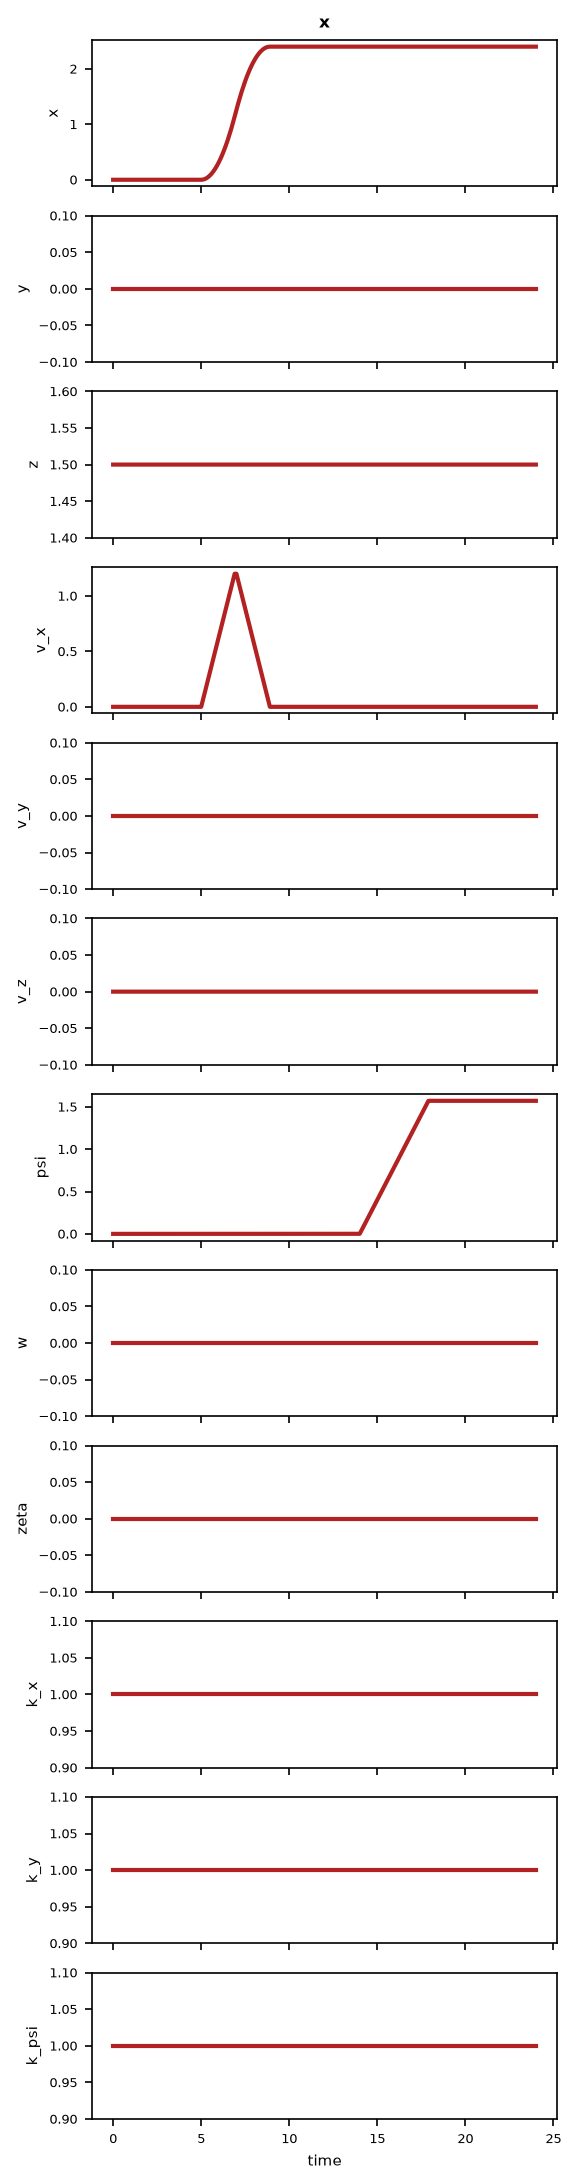

In [7]:
# Plot state tracking
simulator.plot('x')

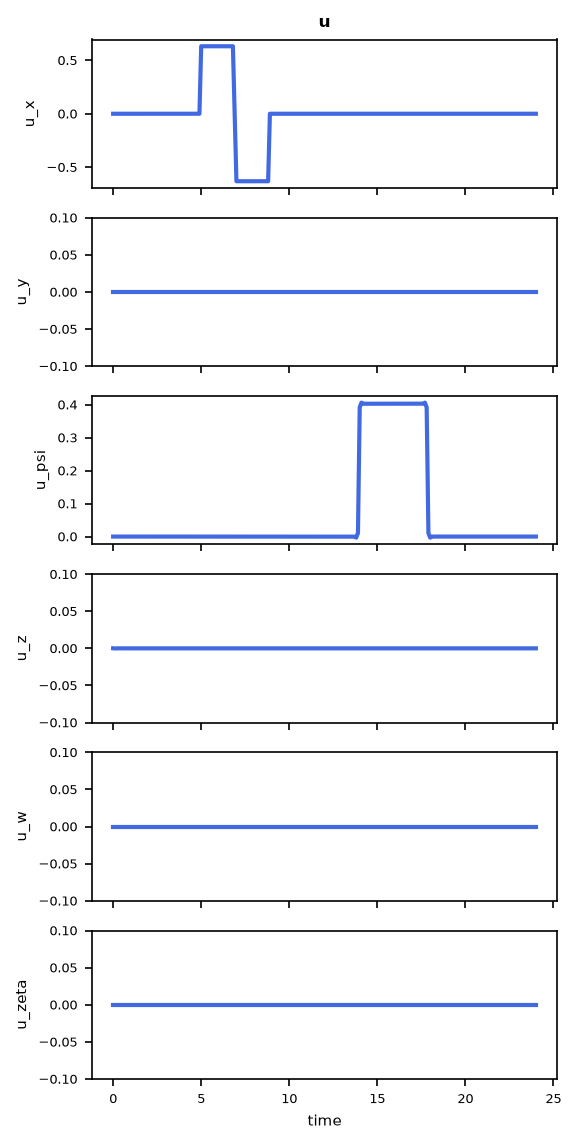

In [8]:
# Plot inputs
simulator.plot('u')

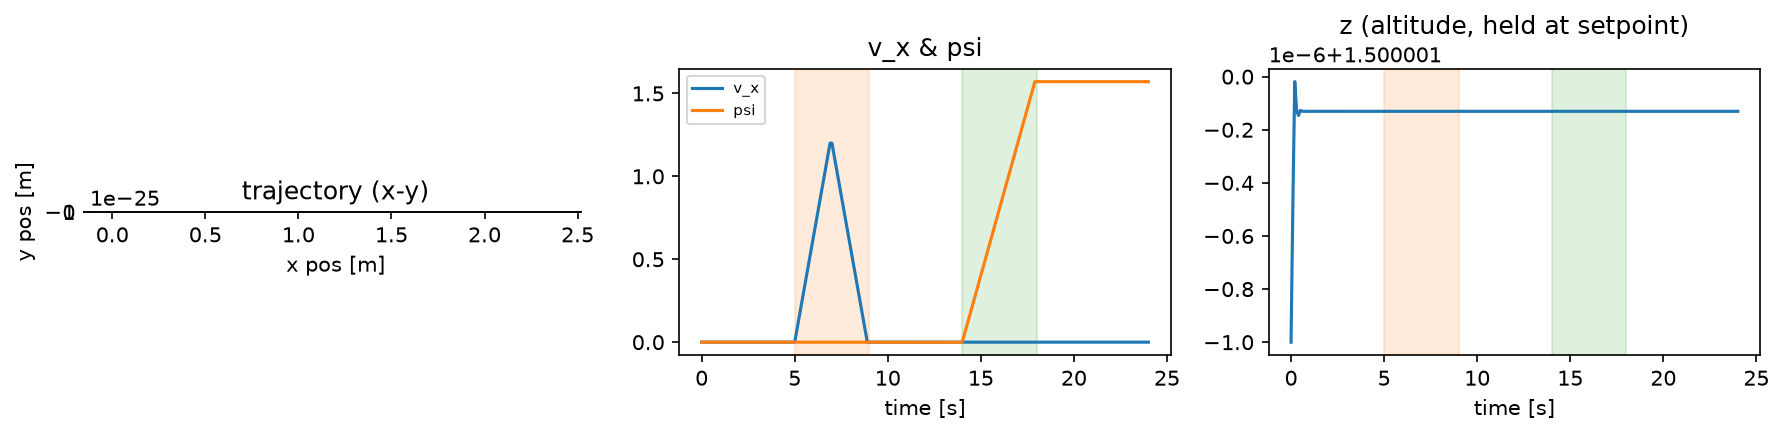

In [9]:
# Plot the x-y trajectory (colored by time), plus v_x and z over time to visually confirm the motifs
fig, ax = plt.subplots(1, 3, figsize=(12, 3), dpi=150)

ax[0].plot(x_sim['x'], x_sim['y'])
ax[0].set_xlabel('x pos [m]')
ax[0].set_ylabel('y pos [m]')
ax[0].set_title('trajectory (x-y)')
ax[0].set_aspect('equal')

ax[1].plot(t_sim, x_sim['v_x'], label='v_x')
ax[1].plot(t_sim, x_sim['psi'], label='psi')
ax[1].set_xlabel('time [s]')
ax[1].set_title('v_x & psi')
ax[1].legend(fontsize=7)

ax[2].plot(t_sim, x_sim['z'])
ax[2].set_xlabel('time [s]')
ax[2].set_title('z (altitude, held at setpoint)')

for a in ax[1:]:
    for (t0, t1, label) in motif_segments:
        if label == 'accel/decel pulse':
            a.axvspan(t0, t1, color='tab:orange', alpha=0.15)
        elif label == 'heading turn':
            a.axvspan(t0, t1, color='tab:green', alpha=0.15)

fig.tight_layout()
plt.show()

# Observability

## Construct the observability matrix in sliding windows

In [10]:
w = 10  # window size (1.0 s at dt=0.1), set to None to use the entire time-series as one window

In [11]:
# Construct O in sliding windows. This is the computationally heavy step: it perturbs every
# state variable and re-simulates the measurements, for every window along the trajectory.
st = time.time()
SEOM = SlidingEmpiricalObservabilityMatrix(simulator, t_sim, x_sim, u_sim, w=w, eps=1e-4)
et = time.time()
print('elapsed time:', et - st)

O_sliding = SEOM.get_observability_matrix()
print(len(O_sliding), 'windows')

elapsed time: 78.89266610145569
232 windows


## Compare an "impaired" sensor set against a "full" sensor set

This is the core experiment from `elaborate_plan.md` Phase 1: does `z` become observable from
optical flow + accelerometer alone, and if so, only during specific motifs?

* **impaired** -- flow deck (`r_x`, `r_y`) + accelerometer (`v_x_dot`, `v_y_dot`) only. This is
  the "no direct vertical height measurement" scenario from the project's grand-prize goal.
* **full** -- the impaired set plus a direct height measurement `z` (as if a ToF/z-ranger sensor
  were present), used only as a sanity-check baseline: `z` should be trivially observable
  everywhere in this case.

In [12]:
# Set each sensor's noise standard deviation, then convert to variance for use as R
measurement_noise_stds = {
    'r_x': 0.05,       # optical flow, x [1/s]
    'r_y': 0.05,       # optical flow, y [1/s]
    'v_x_dot': 0.2,    # accelerometer, x [m/s^2]
    'v_y_dot': 0.2,    # accelerometer, y [m/s^2]
    'z': 0.02,         # direct height/ToF measurement [m] ("full" sensor set only)
}
measurement_noise_vars = {key: val ** 2 for key, val in measurement_noise_stds.items()}

impaired_sensors = ['r_x', 'r_y', 'v_x_dot', 'v_y_dot']
full_sensors = impaired_sensors + ['z']

In [13]:
# Choose states of interest
o_states = ['z', 'v_x', 'v_y', 'psi']

# Choose time-steps to use from O (cannot be larger than the window size w defined above)
window_size = w
o_time_steps = np.arange(0, window_size, step=1)

sensor_sets = {'impaired (flow + accel only)': impaired_sensors,
               'full (flow + accel + height)': full_sensors}

min_error_variance = {}
for label, sensors in sensor_sets.items():
    o_measurement_noise_vars = {key: measurement_noise_vars[key] for key in sensors}

    SFO = SlidingFisherObservability(SEOM.O_df_sliding, time=SEOM.t_sim, lam=1e-8,
                                     R=o_measurement_noise_vars,
                                     states=o_states, sensors=sensors, time_steps=o_time_steps, w=None)

    EV = SFO.get_minimum_error_variance()
    try:
        EV = EV.bfill().ffill()
    except AttributeError:
        EV = EV.fillna(method='bfill').fillna(method='ffill')

    min_error_variance[label] = EV

min_error_variance['full (flow + accel + height)'].head()

,time,time_initial,z,v_x,v_y,psi
0,0.0,0.0,0.00004,0.000563,0.000563,100000000.0
1,0.1,0.0,0.00004,0.000563,0.000563,100000000.0
2,0.2,0.0,0.00004,0.000563,0.000563,100000000.0
3,0.3,0.0,0.00004,0.000563,0.000563,100000000.0
4,0.4,0.0,0.00004,0.000563,0.000563,100000000.0


## Plot z's minimum error variance over time, for each sensor set

If the paper's finding transfers to our model, we should see the impaired sensor set's `z` error
variance drop sharply (better observability) only during the acceleration/deceleration pulse
(shaded orange), stay flat/high during hover, and *not* meaningfully improve during the heading
turn (shaded green) -- while the full sensor set's `z` error variance should stay low throughout.

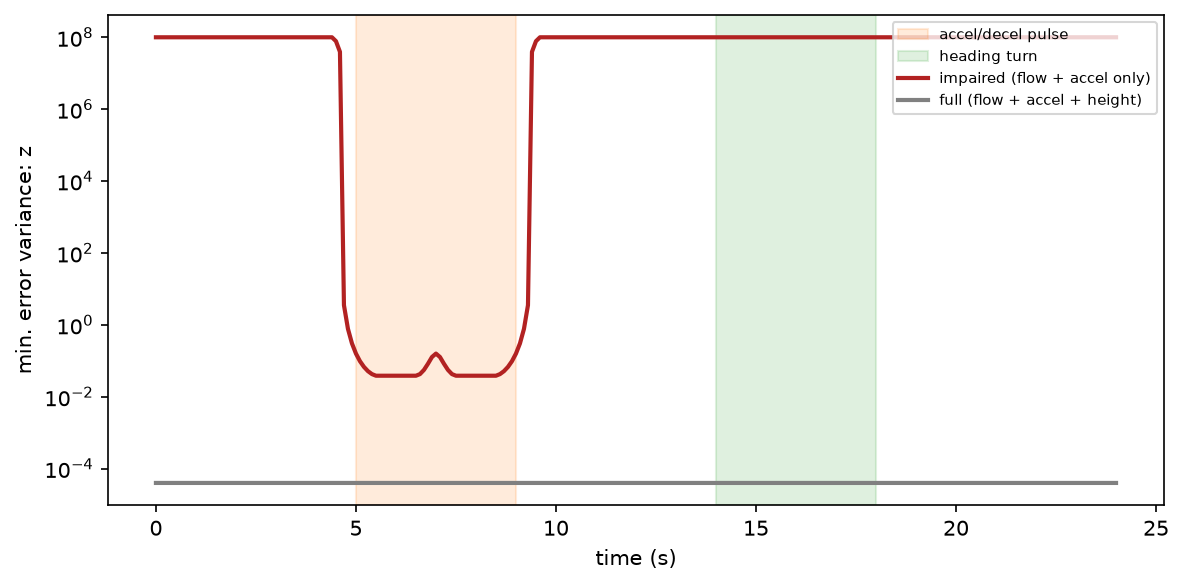

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4), dpi=150)

for (t0, t1, label) in motif_segments:
    if label == 'accel/decel pulse':
        ax.axvspan(t0, t1, color='tab:orange', alpha=0.15, label='accel/decel pulse')
    elif label == 'heading turn':
        ax.axvspan(t0, t1, color='tab:green', alpha=0.15, label='heading turn')

colors = {'impaired (flow + accel only)': 'firebrick', 'full (flow + accel + height)': 'gray'}
for label, EV in min_error_variance.items():
    ax.plot(EV['time'], EV['z'], label=label, color=colors.get(label), linewidth=2.0)

ax.set_yscale('log')
ax.set_xlabel('time (s)')
ax.set_ylabel('min. error variance: z')

# De-duplicate the axvspan legend entries
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=7, loc='upper right')

fig.tight_layout()
plt.show()

## Per-state error-variance grid, impaired sensor set only

Same style as `fly_wind_example.ipynb`'s final plot, but only for the impaired (flow + accel)
sensor set, so we can also see how `v_x`, `v_y`, and `psi` observability behave across the same
motifs.

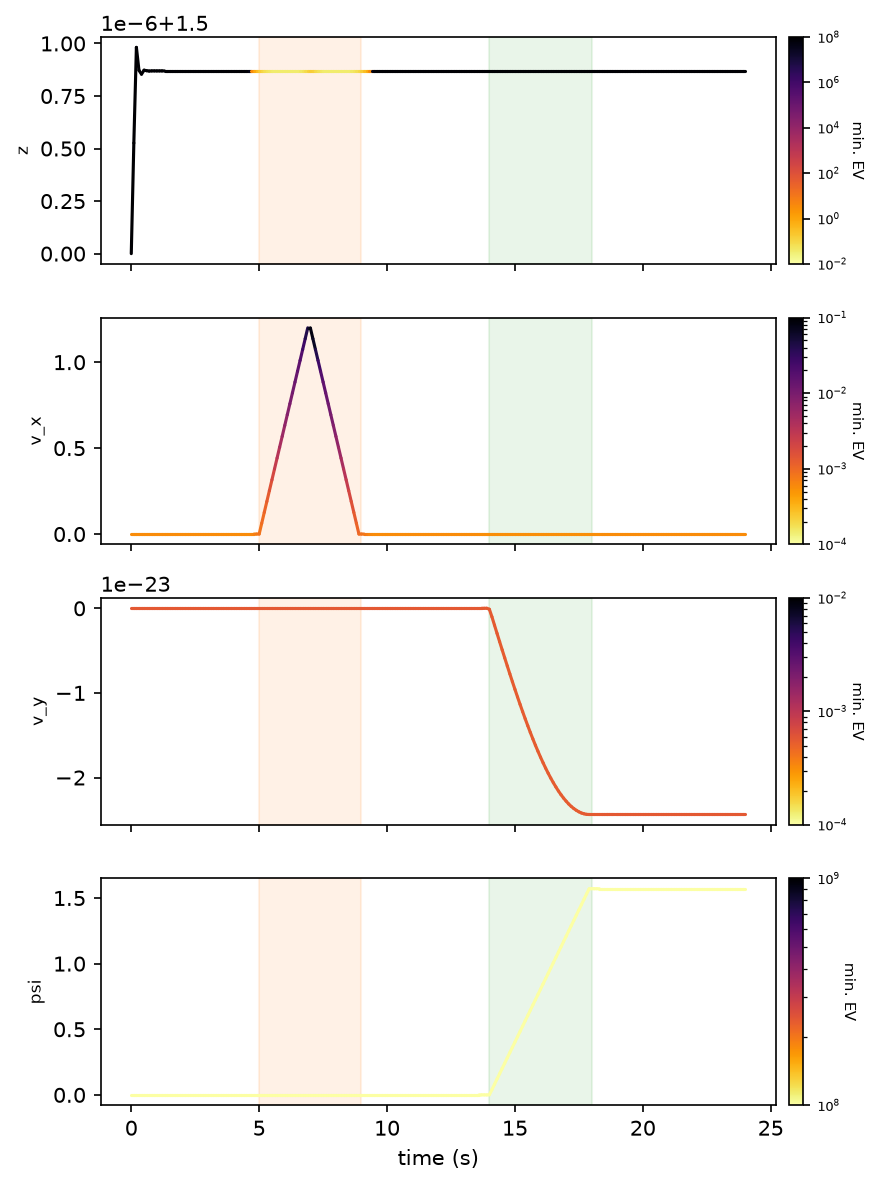

In [15]:
EV_impaired = min_error_variance['impaired (flow + accel only)']

cmap = 'inferno_r'
n_state = len(o_states)

fig, ax = plt.subplots(n_state, 1, figsize=(6, n_state * 2), dpi=150, sharex=True)
ax = np.atleast_1d(ax)

for n, state_name in enumerate(o_states):
    ev = EV_impaired[state_name].values
    min_ev = np.nanmin(ev[ev > 0]) if np.any(ev > 0) else 1e-6
    max_ev = np.nanmax(ev)
    log_tick_low = int(np.floor(np.log10(max(min_ev, 1e-12))))
    log_tick_high = int(np.ceil(np.log10(max(max_ev, min_ev * 10))))
    cnorm = mpl.colors.LogNorm(10 ** log_tick_low, 10 ** log_tick_high)

    colorline(EV_impaired['time'].values, x_sim[state_name][:len(EV_impaired)], ev,
              ax=ax[n], cmap=cmap, norm=cnorm)

    for (t0, t1, label) in motif_segments:
        if label == 'accel/decel pulse':
            ax[n].axvspan(t0, t1, color='tab:orange', alpha=0.1)
        elif label == 'heading turn':
            ax[n].axvspan(t0, t1, color='tab:green', alpha=0.1)

    ax[n].set_ylabel(state_name, fontsize=8)

    cax = ax[n].inset_axes([1.02, 0.0, 0.02, 1.0])
    cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=cnorm, cmap=cmap), cax=cax)
    cbar.set_label('min. EV', rotation=270, fontsize=7, labelpad=8)
    cbar.ax.tick_params(labelsize=6)

ax[-1].set_xlabel('time (s)')
fig.tight_layout()
plt.show()

# Conclusion

With only optical flow (`r_x`, `r_y`) and accelerometer (`v_x_dot`, `v_y_dot`) measurements -- no
direct height sensor -- altitude `z`'s minimum error variance should drop specifically during the
horizontal acceleration/deceleration segment, and stay flat during hover and the heading turn.
That would confirm, on this project's own crazyflie model (not just the reference paper's model),
the counter-intuitive design implication from `elaborate_plan.md`: to make altitude observable
without a height sensor, the Crazyflie should fly brief **horizontal acceleration/deceleration
pulses**, not vertical bobbing or turning.

This notebook is the Phase 1 ("model & simulation replication") deliverable from
`elaborate_plan.md`. The same `DroneSimulator` used here can generate the larger simulated
trajectory dataset needed for Phase 2 (training the ANN altitude estimator), and the sensor-noise
assumptions above (`measurement_noise_stds`) should eventually be replaced with values measured
from the real Flow deck v2 and onboard IMU.

# Exercises

1. Change the accel/decel pulse magnitude or duration -- how much horizontal acceleration is
   "enough" to make `z` observable at a given sensor noise level?
2. Add a second, independent accel pulse in the `v_y` (lateral) direction -- does it help `z`
   observability the same way a `v_x` pulse does?
3. Try the `full_sensors` set but with a much larger `z` noise standard deviation (a noisier
   height sensor) -- at what noise level does the impaired sensor set start to out-perform it
   during the accel/decel pulse?